# Feature Engineering

Create model variables from cleaned data:
- Y: Return differential (US - EU)
- X1: EUR/USD change
- X2: Monetary policy differential (Fed - ECB)
- X3: Volatility differential (VIX - VSTOXX)
- X4: Tech sector differential (US - EU)

## 1. Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load cleaned merged data
df = pd.read_csv('../02_data_processed/final_merged_data.csv', index_col='date', parse_dates=True)

print(f"Loaded: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print("\nFirst rows:")
print(df.head())

Loaded: (240, 9)
Columns: ['ecb_rate', 'fed_rate', 'spxtr_return', 'stoxx50gr_return', 'eurusd', 'vix', 'vstoxx', 'us_tech_return', 'eu_tech_return']

First rows:
            ecb_rate  fed_rate  spxtr_return  stoxx50gr_return  eurusd    vix  \
date                                                                            
2005-01-31       2.0      2.28     -0.024375           -0.0287  1.3034  13.39   
2005-02-28       2.0      2.50      0.021044            0.0452  1.3238  11.68   
2005-03-31       2.0      2.63     -0.017708           -0.0217  1.2963  13.14   
2005-04-30       2.0      2.79     -0.018966           -0.0387  1.2873  14.46   
2005-05-31       2.0      3.00      0.031819            0.0147  1.2310  13.95   

            vstoxx  us_tech_return  eu_tech_return  
date                                                
2005-01-31   13.63        0.001506           -0.02  
2005-02-28   12.64       -0.019549            0.03  
2005-03-31   12.88       -0.035276           -0.02  
2005

## 2. Create Y (Dependent Variable)

Return differential = US return - EU return

Y stats:
count    240.000000
mean       0.003251
std        0.035581
min       -0.103236
25%       -0.018157
50%        0.001096
75%        0.020910
max        0.123328
Name: Y, dtype: float64


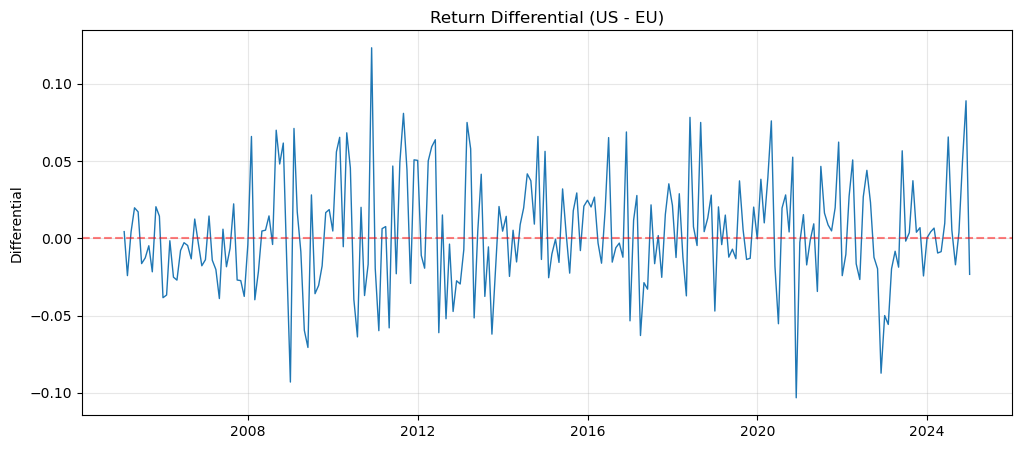

In [2]:
# Y = S&P 500 return - EuroStoxx 50 return
df['Y'] = df['spxtr_return'] - df['stoxx50gr_return']

print(f"Y stats:")
print(df['Y'].describe())

# Plot Y over time
plt.figure(figsize=(12, 5))
plt.plot(df.index, df['Y'], linewidth=1)
plt.axhline(y=0, color='r', linestyle='--', alpha=0.5)
plt.title('Return Differential (US - EU)')
plt.ylabel('Differential')
plt.grid(True, alpha=0.3)
plt.show()

## 3. Create X1 (EUR/USD Change)

In [3]:
# X1 = Monthly change in EUR/USD
df['X1'] = df['eurusd'].pct_change()

print(f"X1 stats:")
print(df['X1'].describe())
print(f"\nMissing values: {df['X1'].isnull().sum()}")

X1 stats:
count    239.000000
mean      -0.000615
std        0.026375
min       -0.097206
25%       -0.015796
50%       -0.001202
75%        0.016217
max        0.100961
Name: X1, dtype: float64

Missing values: 1


## 4. Create X2 (Monetary Policy Differential)

In [4]:
# X2 = Fed rate - ECB rate
df['X2'] = df['fed_rate'] - df['ecb_rate']

print(f"X2 stats:")
print(df['X2'].describe())

X2 stats:
count    240.000000
mean       0.373333
std        1.191647
min       -3.040000
25%       -0.592500
50%        0.220000
75%        1.270000
max        2.490000
Name: X2, dtype: float64


## 5. Create X3 (Volatility Differential)

In [5]:
# X3 = VIX - VSTOXX
df['X3'] = df['vix'] - df['vstoxx']

print(f"X3 stats:")
print(df['X3'].describe())

X3 stats:
count    240.000000
mean      -2.810042
std        3.025211
min      -13.120000
25%       -4.412500
50%       -2.530000
75%       -0.490000
max        4.220000
Name: X3, dtype: float64


## 6. Create X4 (Tech Sector Differential)

In [6]:
# X4 = US tech return - EU tech return
df['X4'] = df['us_tech_return'] - df['eu_tech_return']

print(f"X4 stats:")
print(df['X4'].describe())

X4 stats:
count    240.000000
mean       0.005406
std        0.076218
min       -0.222100
25%       -0.039398
50%       -0.000707
75%        0.044683
max        0.247365
Name: X4, dtype: float64


## 7. Check for Missing Values

In [7]:
# Check missing values in model variables
model_vars = ['Y', 'X1', 'X2', 'X3', 'X4']
print("Missing values:")
print(df[model_vars].isnull().sum())

# Drop rows with any missing values
df_model = df[model_vars].dropna()

print(f"\nBefore: {len(df)} rows")
print(f"After dropping NaN: {len(df_model)} rows")

Missing values:
Y     0
X1    1
X2    0
X3    0
X4    0
dtype: int64

Before: 240 rows
After dropping NaN: 239 rows


Due to date alignment in the previous step and the percentage change calculation for X1 (EUR/USD), the first observation (January 2005) was lost. The `.pct_change()` function requires a previous value to calculate the change, which is not available for the first row.

Final dataset: 239 observations (February 2005 - December 2024)

## 8. Correlation Analysis

Correlation with Y:
Y     1.000000
X4    0.162952
X2   -0.097480
X3   -0.172585
X1   -0.599291
Name: Y, dtype: float64


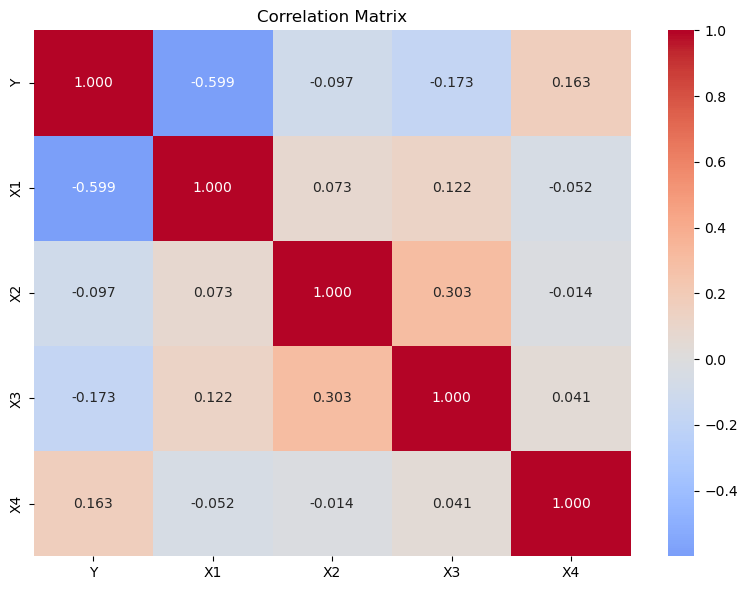

In [8]:
# Correlation matrix
corr = df_model.corr()
print("Correlation with Y:")
print(corr['Y'].sort_values(ascending=False))

# Heatmap
import seaborn as sns
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

## 9. Summary Statistics

In [9]:
print("Model variables summary:")
print(df_model.describe())

print("\nFirst rows:")
print(df_model.head(10))

Model variables summary:
                Y          X1          X2          X3          X4
count  239.000000  239.000000  239.000000  239.000000  239.000000
mean     0.003246   -0.000615    0.373724   -2.820795    0.005338
std      0.035655    0.026375    1.194133    3.026960    0.076370
min     -0.103236   -0.097206   -3.040000  -13.120000   -0.222100
25%     -0.018242   -0.015796   -0.595000   -4.425000   -0.039490
50%      0.000431   -0.001202    0.200000   -2.540000   -0.000899
75%      0.021047    0.016217    1.280000   -0.530000    0.046968
max      0.123328    0.100961    2.490000    4.220000    0.247365

First rows:
                   Y        X1    X2    X3        X4
date                                                
2005-02-28 -0.024156  0.015651  0.50 -0.96 -0.049549
2005-03-31  0.003992 -0.020774  0.63  0.26 -0.015276
2005-04-30  0.019734 -0.006943  0.79 -0.02  0.089422
2005-05-31  0.017119 -0.043735  1.00 -0.38 -0.112884
2005-06-30 -0.016380 -0.016816  1.04 -0.89  0.0167

## 10. Save Model Data

In [10]:
# Save to CSV
df_model.to_csv('../02_data_processed/model_data.csv')
print(f"Saved: model_data.csv ({df_model.shape})")
print(f"Ready for modeling")

Saved: model_data.csv ((239, 5))
Ready for modeling


## Summary

Created 5 model variables:
- Y: Return differential (US - EU equity returns)
- X1: EUR/USD monthly change
- X2: Fed rate - ECB rate
- X3: VIX - VSTOXX
- X4: US tech - EU tech returns

Dataset ready for regression analysis.